SCENARIO 1: USER-BASED CF
NOORIN NASHIKA M - 24BAD084
Dataset:
     user_id  movie_id  rating
0         1       101       5
1         1       102       4
2         1       103       3
3         2       101       4
4         2       102       5
5         2       104       2
6         3       101       2
7         3       103       5
8         3       104       4
9         4       102       4
10        4       103       3
11        5       101       5
12        5       104       3

User Similarity:
 user_id         1         2         3         4         5
user_id                                                  
1        1.000000  0.843274  0.527046  0.707107  0.606339
2        0.843274  1.000000  0.355556  0.596285  0.664703
3        0.527046  0.355556  1.000000  0.447214  0.562441
4        0.707107  0.596285  0.447214  1.000000  0.000000
5        0.606339  0.664703  0.562441  0.000000  1.000000

Recommendations for User 1:
 movie_id
104    1.523916
Name: 1, dtype: float64

RMSE: 1.460

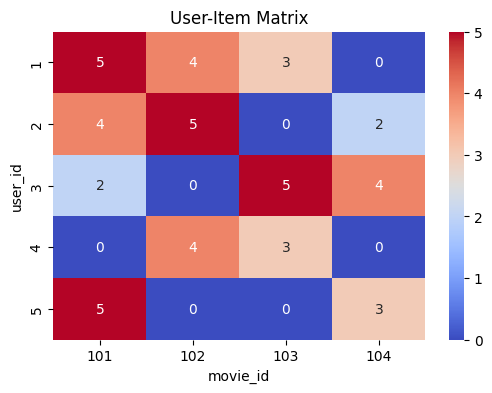

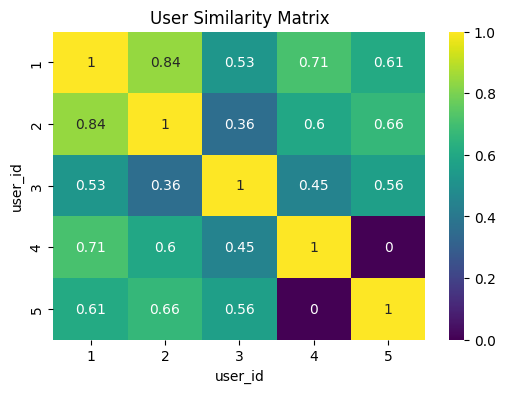

In [2]:
# ==============================
# SCENARIO 1: USER-BASED CF
# ==============================
print("SCENARIO 1: USER-BASED CF")
print("NOORIN NASHIKA M - 24BAD084")
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Create Dataset
data = {
    'user_id': [1,1,1,2,2,2,3,3,3,4,4,5,5],
    'movie_id': [101,102,103,101,102,104,101,103,104,102,103,101,104],
    'rating': [5,4,3,4,5,2,2,5,4,4,3,5,3]
}

df = pd.DataFrame(data)

print("Dataset:\n", df)

# Step 2: Create User-Item Matrix
user_item = df.pivot_table(index='user_id', columns='movie_id', values='rating')

# Step 3: Fill Missing Values
user_item_filled = user_item.fillna(0)

# Step 4: Compute Similarity
user_similarity = cosine_similarity(user_item_filled)

user_sim_df = pd.DataFrame(user_similarity,
                          index=user_item.index,
                          columns=user_item.index)

print("\nUser Similarity:\n", user_sim_df)

# Step 5: Predict Ratings
def predict_ratings(matrix, similarity):
    return similarity.dot(matrix) / np.array([np.abs(similarity).sum(axis=1)]).T

predictions = predict_ratings(user_item_filled.values, user_similarity)

pred_df = pd.DataFrame(predictions,
                       index=user_item.index,
                       columns=user_item.columns)

# Step 6: Recommend Movies
def recommend(user_id, original, predicted, n=2):
    unseen = original.loc[user_id][original.loc[user_id].isna()].index
    return predicted.loc[user_id, unseen].sort_values(ascending=False).head(n)

print("\nRecommendations for User 1:\n", recommend(1, user_item, pred_df))

# Step 7: Evaluation
actual = user_item_filled.values.flatten()
pred = pred_df.values.flatten()

rmse = np.sqrt(mean_squared_error(actual, pred))
mae = mean_absolute_error(actual, pred)

print("\nRMSE:", rmse)
print("MAE:", mae)

# Step 8: Visualization
plt.figure(figsize=(6,4))
sns.heatmap(user_item_filled, annot=True, cmap="coolwarm")
plt.title("User-Item Matrix")
plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(user_sim_df, annot=True, cmap="viridis")
plt.title("User Similarity Matrix")
plt.show()